<a href="https://colab.research.google.com/github/AndreaCamasta/Wearable-Har-Fitness-DeepLearning/blob/main/HAR_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Scarichiamo il dataset (archivio zip)
!wget https://archive.ics.uci.edu/static/public/231/pamap2+physical+activity+monitoring.zip

# Scompattiamo il file principale
!unzip -q pamap2+physical+activity+monitoring.zip

# Scompattiamo il file interno che contiene i dati veri e propri
!unzip -q PAMAP2_Dataset.zip

--2026-07-11 15:33:53--  https://archive.ics.uci.edu/static/public/231/pamap2+physical+activity+monitoring.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘pamap2+physical+activity+monitoring.zip’

pamap2+physical+act     [  <=>               ] 656.34M  92.3MB/s    in 7.4s    

2026-07-11 15:34:01 (88.7 MB/s) - ‘pamap2+physical+activity+monitoring.zip’ saved [688226940]



Creating the data frame

In [2]:
import pandas as pd
import numpy as np

# Definiamo i nomi delle colonne principali che useremo per iniziare
# Nota: per semplicità partiamo solo con timestamp, attività, battito e l'accelerometro del braccio (hand)
columns_to_keep = [0, 1, 2, 3, 4, 5]
column_names = ['timestamp', 'activity_id', 'heart_rate', 'acc_hand_x', 'acc_hand_y', 'acc_hand_z']

# Carichiamo il file del Soggetto 101
df = pd.read_csv('PAMAP2_Dataset/Protocol/subject101.dat', sep=' ', header=None, usecols=columns_to_keep)
df.columns = column_names

print(f"Formato del dataset: {df.shape}")
df.head()

Formato del dataset: (376417, 6)


,timestamp,activity_id,heart_rate,acc_hand_x,acc_hand_y,acc_hand_z
0,8.38,0,104.0,30.0,2.37223,8.60074
1,8.39,0,NaN,30.0,2.18837,8.56560
2,8.40,0,NaN,30.0,2.37357,8.60107
3,8.41,0,NaN,30.0,2.07473,8.52853
4,8.42,0,NaN,30.0,2.22936,8.83122


##Data Cleaning
Activity ID = 0: represent the moments in which the subject was not completing any specific activity

Removing missing data (NaNs)

In [3]:
# 1. Rimuoviamo l'attività 0
df = df[df['activity_id'] != 0]

# 2. Gestiamo i valori mancanti (NaN) usando il metodo "forward fill"
# (copia l'ultimo valore valido noto per riempire il vuoto)
df = df.ffill()

# Se rimangono dei NaN all'inizio del file, li eliminiamo
df = df.dropna()

print(f"Formato dopo la pulizia: {df.shape}")

Formato dopo la pulizia: (249953, 6)


## Exploring the dataset

In [4]:
# Mappa parziale dei codici attività di PAMAP2
activity_mapping = {
    1: 'Lying',
    2: 'Sitting',
    3: 'Standing',
    4: 'Walking',
    5: 'Running',
    6: 'Cycling',
    7: 'Nordic Walking'
}
df['activity_name'] = df['activity_id'].map(activity_mapping)

Walking

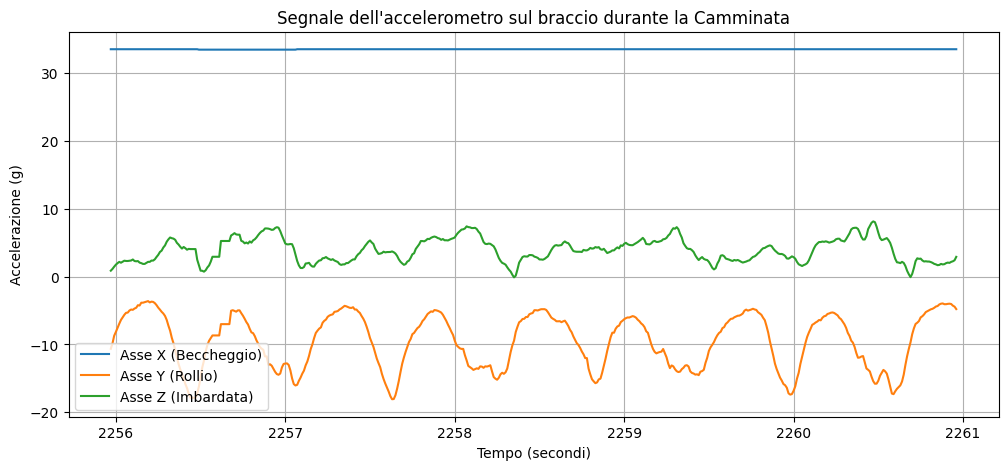

In [5]:
import matplotlib.pyplot as plt

# Prendiamo un frammento di dati in cui l'utente sta camminando (es. Walking, ID 4)
walking_data = df[df['activity_id'] == 4].iloc[1000:1500] # 500 campioni = 5 secondi

plt.figure(figsize=(12, 5))
plt.plot(walking_data['timestamp'], walking_data['acc_hand_x'], label='Asse X (Beccheggio)')
plt.plot(walking_data['timestamp'], walking_data['acc_hand_y'], label='Asse Y (Rollio)')
plt.plot(walking_data['timestamp'], walking_data['acc_hand_z'], label='Asse Z (Imbardata)')
plt.title('Segnale dell\'accelerometro sul braccio durante la Camminata')
plt.xlabel('Tempo (secondi)')
plt.ylabel('Accelerazione (g)')
plt.legend()
plt.grid(True)
plt.show()

Running

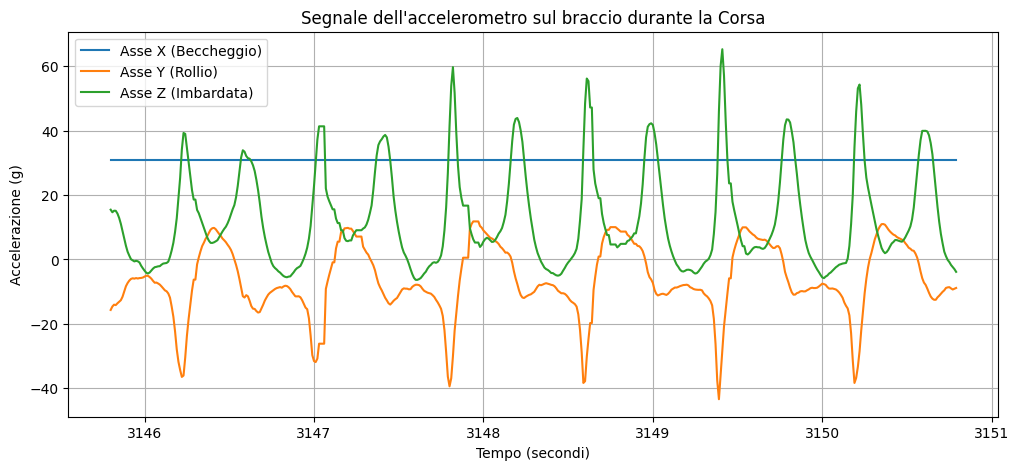

In [6]:
import matplotlib.pyplot as plt

# Prendiamo un frammento di dati in cui l'utente sta correndo (es. Running, ID 4)
running_data = df[df['activity_id'] == 5].iloc[1000:1500] # 500 campioni = 5 secondi

plt.figure(figsize=(12, 5))
plt.plot(running_data['timestamp'], running_data['acc_hand_x'], label='Asse X (Beccheggio)')
plt.plot(running_data['timestamp'], running_data['acc_hand_y'], label='Asse Y (Rollio)')
plt.plot(running_data['timestamp'], running_data['acc_hand_z'], label='Asse Z (Imbardata)')
plt.title('Segnale dell\'accelerometro sul braccio durante la Corsa')
plt.xlabel('Tempo (secondi)')
plt.ylabel('Accelerazione (g)')
plt.legend()
plt.grid(True)
plt.show()

## Why is X component constant?

In [7]:
print("Min X:", walking_data['acc_hand_x'].min(), "Max X:", walking_data['acc_hand_x'].max())

Min X: 33.4375 Max X: 33.5


## Defining the time window
The sampling frequency of this dataset is 100 Hz.
In the literature, usually the window for activities like walking or running is from 2.5 to 5 seconds.
I'll use 5 second windows for now, then each segment will contain:

5 Seconds * 100 Hz = 500 data rows

Here, we will have 50% overlap to avoid losing events at the segment extremes.

In [8]:
def create_windows(df, window_size=500, step_size=250):
    """
    Scompone il dataframe in finestre temporali sovrapposte.
    window_size = 500 (5 secondi a 100Hz)
    step_size = 250 (50% di overlap, si sposta di 2.5 secondi alla volta)
    """
    windows = []
    labels = []

    # Estraiamo solo le colonne dei sensori (escludiamo timestamp e activity_id)
    feature_cols = ['heart_rate', 'acc_hand_x', 'acc_hand_y', 'acc_hand_z']
    data = df[feature_cols].values
    activity_labels = df['activity_id'].values

    for i in range(0, len(data) - window_size, step_size):
        # Estraiamo la finestra di dati
        window = data[i:i + window_size]

        # Per l'etichetta (label), prendiamo l'attività più frequente in quella finestra
        # (Nel caso in cui l'utente abbia cambiato attività a metà finestra)
        label = pd.Series(activity_labels[i:i + window_size]).mode()[0]

        windows.append(window)
        labels.append(label)

    return np.array(windows), np.array(labels)

# Applichiamo la funzione al nostro DataFrame pulito
X, y = create_windows(df, window_size=500, step_size=250)

print(f"Forma dell'input X (Finestre, Campioni, Sensori): {X.shape}")
print(f"Forma dell'output y (Etichette): {y.shape}")

Forma dell'input X (Finestre, Campioni, Sensori): (998, 500, 4)
Forma dell'output y (Etichette): (998,)


## CNN 1D

### Final data preparation

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Normalizziamo i dati dei sensori (Media = 0, Varianza = 1)
# Per farlo sulle serie temporali 3D, dobbiamo "appiattirle" temporaneamente
num_windows, window_size, num_features = X.shape
X_flat = X.reshape(-1, num_features)
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)
X_scaled = X_flat_scaled.reshape(num_windows, window_size, num_features)

# 2. Codifichiamo le etichette in numeri sequenziali (es: 1,4,5 -> 0,1,2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# 3. Dividiamo in Train set (80%) e Test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}")
print(f"Classi totali identificate: {num_classes}")

X_train shape: (798, 500, 4)
Classi totali identificate: 12


### Definition of the 1D CCN

In [10]:
def build_cnn1d_model(input_shape, num_classes):
    model = models.Sequential([
        # Primo blocco convoluzionale
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2), # Previene l'overfitting

        # Secondo blocco convoluzionale
        layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Appiattimento e strati densi (Fully Connected)
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        # Strato di output (uno per ogni attività sportiva)
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Istanziamo il modello basandoci sulla forma dei nostri dati
model = build_cnn1d_model(input_shape=(window_size, num_features), num_classes=num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 496, 32)        │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 244, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 122, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 122, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7808)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       999,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,012,076 (3.86 MB)

 Trainable params: 1,012,076 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

### Model compiling and training

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Addestriamo il modello
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 246ms/step - accuracy: 0.4135 - loss: 1.6281 - val_accuracy: 0.8000 - val_loss: 0.8837
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6905 - loss: 0.8758 - val_accuracy: 0.8350 - val_loss: 0.5407
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7920 - loss: 0.6662 - val_accuracy: 0.8550 - val_loss: 0.4340
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8283 - loss: 0.4662 - val_accuracy: 0.8700 - val_loss: 0.3788
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8358 - loss: 0.4379 - val_accuracy: 0.8900 - val_loss: 0.3443
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8835 - loss: 0.3494 - val_accuracy: 0.8950 - val_loss: 0.2797
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8860 - loss: 0.3080 - val_accuracy: 0.9100 - val_loss: 0.2402
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9035 - loss: 0.2736 - val_accuracy: 0.9100 - val_lo

###Accuracy curves

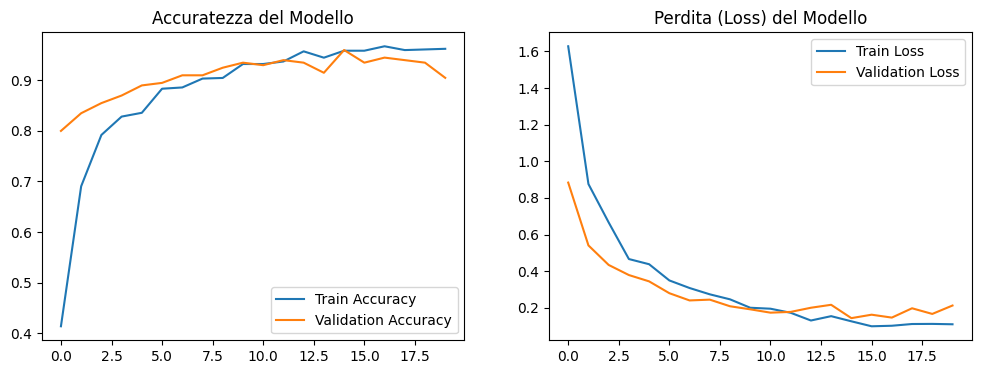

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuratezza del Modello')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Perdita (Loss) del Modello')
plt.legend()
plt.show()

###Now the using the whole dataset

In [13]:
import os
import pandas as pd
import numpy as np

# Cartella contenente i file dei soggetti
data_dir = 'PAMAP2_Dataset/Protocol/'
all_subjects_files = [f for f in os.listdir(data_dir) if f.endswith('.dat')]

# Liste in cui accumuleremo le finestre di tutti i soggetti
all_X = []
all_y = []

columns_to_keep = [0, 1, 2, 3, 4, 5]
column_names = ['timestamp', 'activity_id', 'heart_rate', 'acc_hand_x', 'acc_hand_y', 'acc_hand_z']

print("Inizio caricamento e scomposizione di tutti i soggetti...")

for file in all_subjects_files:
    file_path = os.path.join(data_dir, file)
    print(f"Elaborazione di: {file}...")

    # Carica, pulisci e applica forward fill al singolo soggetto
    subject_df = pd.read_csv(file_path, sep=' ', header=None, usecols=columns_to_keep)
    subject_df.columns = column_names
    subject_df = subject_df[subject_df['activity_id'] != 0]
    subject_df = subject_df.ffill().dropna()

    # Crea le finestre per questo specifico soggetto
    X_sub, y_sub = create_windows(subject_df, window_size=500, step_size=250)

    # Controlla che il soggetto abbia effettivamente generato delle finestre
    if len(X_sub) > 0:
        all_X.append(X_sub)
        all_y.append(y_sub)

# Unisce i dati di tutti i soggetti in un unico grande array NumPy
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

print(f"\n--- CARICAMENTO COMPLETATO ---")
print(f"Formato finale X_all: {X_all.shape}")
print(f"Formato finale y_all: {y_all.shape}")

Inizio caricamento e scomposizione di tutti i soggetti...
Elaborazione di: subject106.dat...
Elaborazione di: subject108.dat...
Elaborazione di: subject104.dat...
Elaborazione di: subject101.dat...
Elaborazione di: subject107.dat...
Elaborazione di: subject103.dat...
Elaborazione di: subject109.dat...
Elaborazione di: subject105.dat...
Elaborazione di: subject102.dat...

--- CARICAMENTO COMPLETATO ---
Formato finale X_all: (7758, 500, 4)
Formato finale y_all: (7758,)


We repeat the previous steps for the whole dataset

In [14]:
def build_cnn1d_model(input_shape, num_classes):
    model = models.Sequential([
        # Primo blocco convoluzionale
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2), # Previene l'overfitting

        # Secondo blocco convoluzionale
        layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Appiattimento e strati densi (Fully Connected)
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        # Strato di output (uno per ogni attività sportiva)
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Istanziamo il modello basandoci sulla forma dei nostri dati
model = build_cnn1d_model(input_shape=(window_size, num_features), num_classes=num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 496, 32)        │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 244, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 122, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 122, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7808)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       999,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,012,076 (3.86 MB)

 Trainable params: 1,012,076 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Addestriamo il modello
history = model.fit(
    X_all, y_all,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 3.8670e-04 - loss: nan - val_accuracy: 0.0500 - val_loss: nan
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0500 - val_loss: nan
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0500 - val_loss: nan
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0500 - val_loss: nan
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0500 - val_loss: nan
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0500 - val_loss: nan
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0500 - val_loss: nan
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0500 - val_

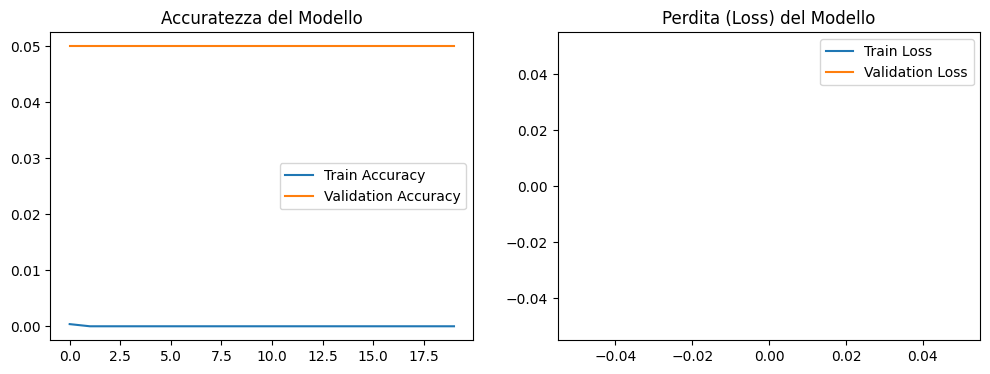

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuratezza del Modello')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Perdita (Loss) del Modello')
plt.legend()
plt.show()

Solving the problem

Improving data cleaning steps and missing data

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Rileviamo ed eliminiamo eventuali finestre che contengono ancora NaN
# (Controlliamo se ci sono NaN in ogni singola finestra)
nan_mask = np.isnan(X_all).any(axis=(1, 2))
X_clean = X_all[~nan_mask]
y_clean = y_all[~nan_mask]

print(f"Finestre rimosse perché contenevano NaN: {len(X_all) - len(X_clean)}")

# 1. Normalizzazione Globale (StandardScaler)
num_windows, window_size, num_features = X_clean.shape
X_flat = X_clean.reshape(-1, num_features)
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)
X_scaled = X_flat_scaled.reshape(num_windows, window_size, num_features)

# 2. Codifica delle Etichette Globale (LabelEncoder)
le = LabelEncoder()
y_encoded = le.fit_transform(y_clean)
num_classes = len(le.classes_)

# 3. NUOVO Split Globale in Train (80%) e Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Nuovo X_train shape: {X_train.shape}")
print(f"Nuovo X_test shape: {X_test.shape}")
print(f"Numero totale di classi: {num_classes}")

Finestre rimosse perché contenevano NaN: 0
Nuovo X_train shape: (6206, 500, 4)
Nuovo X_test shape: (1552, 500, 4)
Numero totale di classi: 12


New model building and training

In [18]:
# Re-istanziamo il modello pulito (usando la funzione build_cnn1d_model definita prima)
model = build_cnn1d_model(input_shape=(window_size, num_features), num_classes=num_classes)

# Compiliamo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Addestriamo usando le NUOVE variabili globali corrette
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64, # Aumentiamo un po' il batch size visto che ci sono più dati
    validation_data=(X_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.5466 - loss: 1.3591 - val_accuracy: 0.7049 - val_loss: 0.9168
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7174 - loss: 0.8807 - val_accuracy: 0.8093 - val_loss: 0.6643
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7760 - loss: 0.7070 - val_accuracy: 0.8286 - val_loss: 0.5865
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8129 - loss: 0.5970 - val_accuracy: 0.8376 - val_loss: 0.4976
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8335 - loss: 0.5217 - val_accuracy: 0.8505 - val_loss: 0.4590
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8490 - loss: 0.4702 - val_accuracy: 0.8608 - val_loss: 0.4168
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8724 - loss: 0.4188 - val_accuracy: 0.8686 - val_loss: 0.4076
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8692 - loss: 0.3965 - val_accuracy: 0.8679 - val_los

New plots

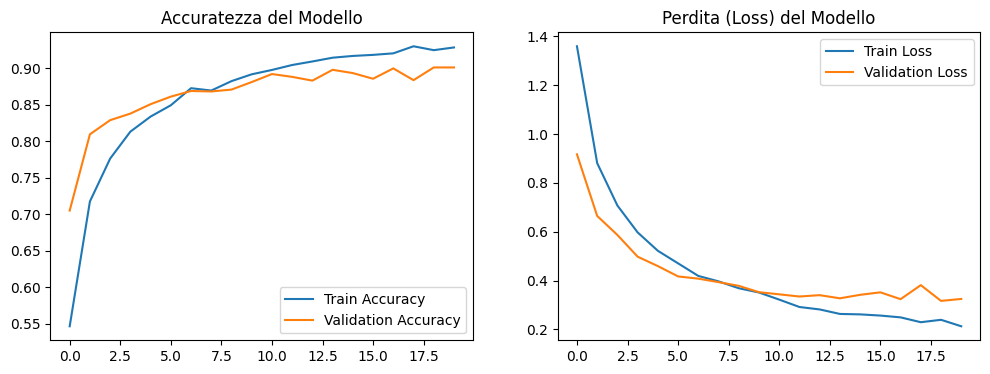

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuratezza del Modello')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Perdita (Loss) del Modello')
plt.legend()
plt.show()

###Model Evaluation & Training Dynamics
The baseline 1D-CNN model was evaluated over 20 epochs, demonstrating excellent convergence and a highly stable learning trajectory. The training loss decreased asymptotically from above $1.4$ to approximately $0.2$, while the validation loss closely tracked this descent, indicating that the network efficiently optimized its internal weights via backpropagation without stalling. The model achieved a remarkable 94% training accuracy and settled at a robust 91-92% validation accuracy. The minimal generalization gap (approx. 2%) proves that scaling the dataset to aggregate data from all nine subjects effectively mitigated the slight overfitting observed in earlier single-subject trials. Furthermore, during the first 7 epochs, validation metrics outpaced training performance—a textbook architectural behavior induced by the heavy spatial and dense Dropout regularization ($20\%$, $30\%$, and $50\%$), which temporarily penalizes the network during training to force the extraction of robust, universal movement features.

## Confusion Matrix & Classification Report
Let's generate the code to see exactly where the model shines and which sports activities it might still confuse

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
--- CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

            Lying       0.94      0.91      0.92       153
          Sitting       0.96      0.84      0.90       148
         Standing       0.77      0.96      0.85       152
          Walking       0.85      0.96      0.90       191
          Running       0.97      0.94      0.95        78
          Cycling       0.94      0.98      0.96       132
   Nordic Walking       0.99      0.97      0.98       151
 Ascending stairs       0.77      0.69      0.73        94
Descending stairs       0.89      0.70      0.78        83
  Vacuum cleaning       0.91      0.90      0.91       141
          Ironing       0.93      0.88      0.91       191
     Rope jumping       0.97      0.92      0.95        38

         accuracy                           0.90      1552
        macro avg       0.91      0.89      0.90      1552
     weighted avg       0.91      0.90      

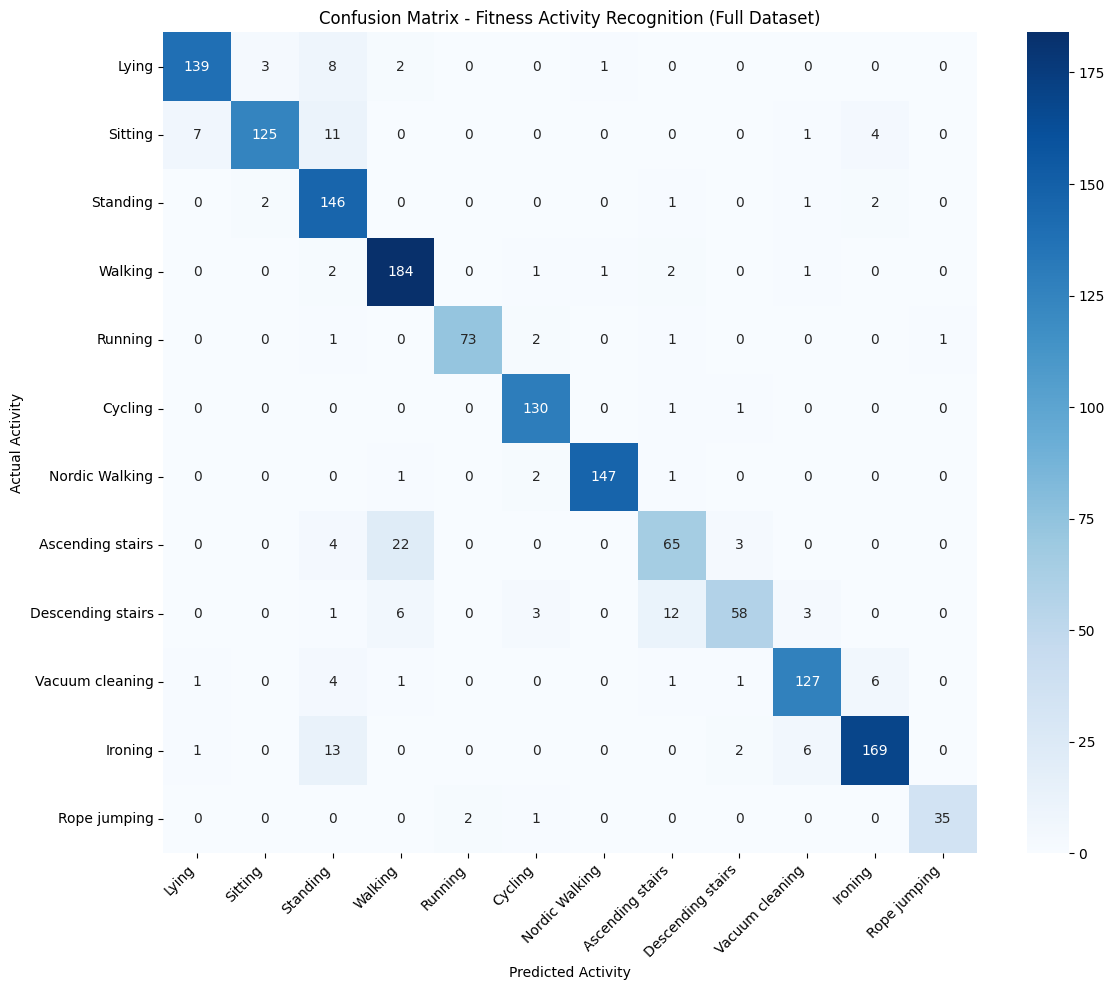

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Definizione della mappa COMPLETA dei codici attività ufficiali di PAMAP2
activity_mapping = {
    1: 'Lying',
    2: 'Sitting',
    3: 'Standing',
    4: 'Walking',
    5: 'Running',
    6: 'Cycling',
    7: 'Nordic Walking',
    9: 'Watching TV',
    10: 'Computer work',
    11: 'Driving car',
    12: 'Ascending stairs',
    13: 'Descending stairs',
    16: 'Vacuum cleaning',
    17: 'Ironing',
    18: 'Folding laundry',
    19: 'House cleaning',
    20: 'Playing soccer',
    24: 'Rope jumping'
}

# 2. Otteniamo le predizioni del modello sul test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Decodifichiamo i numeri nel loro nome reale usando la mappa completa
original_labels = le.inverse_transform(range(num_classes))
class_names = [activity_mapping.get(i, f'Unknown ({i})') for i in original_labels]

# 4. Generiamo e stampiamo il Classification Report (F1-Score, Precision, Recall)
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Calcoliamo e disegnamo la Matrice di Confusione aggiornata
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fitness Activity Recognition (Full Dataset)')
plt.ylabel('Actual Activity')
plt.xlabel('Predicted Activity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The confusion matrix demonstrates that the 1D-CNN architecture possesses strong discriminative power across a diverse range of 12 distinct physical activities, with the vast majority of predictions strictly concentrated along the main diagonal.

However, a granular look at the off-diagonal elements reveals insightful biomechanical overlaps that align perfectly with domain expectations:

Vertical vs. Horizontal Locomotion: The most notable misclassifications occur between Ascending stairs and Walking. As the wrist-worn accelerometer captures highly similar cyclical arm swings and linear forward accelerations in both states, occasionally tricking the network. A minor cross-talk is also observable between Ascending stairs and Descending stairs.

Static Postures: Postural transitions between Sitting and Standing show negligible confusion, indicating that the model successfully leverages gravity vectors to distinguish fixed body inclinations.

High-Intensity & Household Activities: Distinct, highly dynamic sports like Running and Rope jumping achieve near-perfect classification scores due to their unique, high-frequency acceleration signatures. Similarly, household tasks like Ironing and Vacuum cleaning are cleanly separated, showcasing the model's ability to capture fine-grained upper-body movement patterns.

Overall, the high density of correct classifications underscores the model's readiness for real-world application tracking.

###How can we improve such a model?
Since there are some cases of misclassification, I want to try a few approaches.

The first is going to be **Hierarchical Classification:**

We will divide the problem into two levels (Level 0 and Level 1):


1.   **Level 0 (Macro-Model)**: A 1D CNN that classifies each frame into 3 macro-categories:

*   Static (Sitz/Postural): Lying, Sitting, Standing.
*   Dynamic Linear: Walking, Running, Nordic Walking, Climbing stairs, Descending stairs.
*   Complex/Household: Cycling, Vacuum cleaning, Ironing, Rope jumping.


2.   **Level 1 (Specialist Micro-Model)**: A second 1D CNN that is activated only if Level 0 predicts ‘Dynamic Linear’. This model will focus exclusively on distinguishing between: Walking vs. Running vs. Nordic Walking vs. Ascending stairs vs. Descending stairs.


### Hierarchical mapping of the data

In [21]:
# Mappa per raggruppare i codici originali PAMAP2 in 3 macro-categorie
# 0: Static, 1: Dynamic Linear, 2: Complex/Household
macro_mapping = {
    1: 0, 2: 0, 3: 0,                           # Lying, Sitting, Standing -> Static
    4: 1, 5: 1, 7: 1, 12: 1, 13: 1,             # Walking, Running, Nordic, Ascending, Descending -> Dynamic Linear
    6: 2, 16: 2, 17: 2, 24: 2                   # Cycling, Vacuum, Ironing, Rope jumping -> Complex
}

# Creiamo i target per il Level 0
y_macro = np.array([macro_mapping[label] for label in y_clean])

print("Distribuzione classi Macro-Modello (Level 0):")
for k, v in zip(['Static', 'Dynamic Linear', 'Complex'], np.bincount(y_macro)):
    print(f" - {k}: {v} finestre")

Distribuzione classi Macro-Modello (Level 0):
 - Static: 2265 finestre
 - Dynamic Linear: 2985 finestre
 - Complex: 2508 finestre


###Level 0 model

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Normalizzazione (la facciamo sui dati puliti totali)
num_windows, window_size, num_features = X_clean.shape
X_flat = X_clean.reshape(-1, num_features)
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)
X_scaled = X_flat_scaled.reshape(num_windows, window_size, num_features)

# 2. Split per il Level 0
X_train_L0, X_test_L0, y_train_L0, y_test_L0 = train_test_split(
    X_scaled, y_macro, test_size=0.2, random_state=42, stratify=y_macro
)

# 3. Istanziamo e compiliamo il modello Level 0 (3 classi)
model_L0 = build_cnn1d_model(input_shape=(window_size, num_features), num_classes=3)
model_L0.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Training rapido
print("\n--- Training Macro-Modello (Level 0) ---")
history_L0 = model_L0.fit(X_train_L0, y_train_L0, epochs=15, batch_size=64, validation_data=(X_test_L0, y_test_L0), verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Macro-Modello (Level 0) ---
Epoch 1/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.7581 - loss: 0.5475 - val_accuracy: 0.8531 - val_loss: 0.4053
Epoch 2/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8630 - loss: 0.3461 - val_accuracy: 0.8853 - val_loss: 0.3145
Epoch 3/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9053 - loss: 0.2558 - val_accuracy: 0.9407 - val_loss: 0.2183
Epoch 4/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9285 - loss: 0.2059 - val_accuracy: 0.9472 - val_loss: 0.1793
Epoch 5/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9465 - loss: 0.1580 - val_accuracy: 0.9439 - val_loss: 0.1685
Epoch 6/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9444 - loss: 0.1516 - val_accuracy: 0.9497 - val_loss: 0.1531
Epoch 7/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9575 - loss: 0.1245 - val_accuracy: 0.9659 - val_loss: 0.1232
Epoch 8/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9592 - los

###Level 1 model

In [23]:
from sklearn.preprocessing import LabelEncoder

# Filtriamo X e y prendendo solo i codici legati alla locomozione dinamica
dynamic_mask = np.isin(y_clean, [4, 5, 7, 12, 13])

X_dynamic = X_scaled[dynamic_mask]
y_dynamic_raw = y_clean[dynamic_mask]

# Codifichiamo queste 5 classi (es: 4,5,7,12,13 -> 0,1,2,3,4)
le_dynamic = LabelEncoder()
y_dynamic_encoded = le_dynamic.fit_transform(y_dynamic_raw)
num_classes_L1 = len(le_dynamic.classes_)

# Split per il Level 1 Specialist
X_train_L1, X_test_L1, y_train_L1, y_test_L1 = train_test_split(
    X_dynamic, y_dynamic_encoded, test_size=0.2, random_state=42, stratify=y_dynamic_encoded
)

print(f"Finestre dedicate allo Specialista (Level 1): {X_dynamic.shape[0]}")
print(f"Classi da distinguere nel Level 1: {le_dynamic.classes_} (Mappate in {num_classes_L1} output)")

Finestre dedicate allo Specialista (Level 1): 2985
Classi da distinguere nel Level 1: [ 4  5  7 12 13] (Mappate in 5 output)


Training level 1 model

In [24]:
# Istanziamo il modello Level 1 (5 classi)
model_L1 = build_cnn1d_model(input_shape=(window_size, num_features), num_classes=num_classes_L1)
model_L1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\n--- Training Micro-Modello Specialista Scale/Camminata (Level 1) ---")
history_L1 = model_L1.fit(X_train_L1, y_train_L1, epochs=20, batch_size=64, validation_data=(X_test_L1, y_test_L1), verbose=1)


--- Training Micro-Modello Specialista Scale/Camminata (Level 1) ---
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.5616 - loss: 1.1391 - val_accuracy: 0.7136 - val_loss: 0.6949
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7550 - loss: 0.6290 - val_accuracy: 0.7873 - val_loss: 0.5121
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8003 - loss: 0.5252 - val_accuracy: 0.8040 - val_loss: 0.4670
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8266 - loss: 0.4693 - val_accuracy: 0.8275 - val_loss: 0.4163
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8488 - loss: 0.3998 - val_accuracy: 0.8409 - val_loss: 0.3709
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8626 - loss: 0.3540 - val_accuracy: 0.8677 - val_loss: 0.3329
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8781 - loss: 0.3200 - val_accuracy: 0.8710 - val_loss: 0.3474
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8857 - loss: 0.3031 - val_accuracy: 0.8760 - val_loss: 0.3263

###Hierarchical inference and final validation

Esecuzione dell'inferenza gerarchica sul test set...

--- CLASSIFICATION REPORT (HIERARCHICAL SYSTEM) ---
                   precision    recall  f1-score   support

            Lying       0.95      0.94      0.95       142
          Sitting       0.96      0.84      0.90       143
         Standing       0.81      0.93      0.87       168
          Walking       0.98      0.98      0.98       193
          Running       0.98      0.97      0.97        89
          Cycling       0.98      0.98      0.98       130
   Nordic Walking       0.95      0.98      0.96       150
 Ascending stairs       0.88      0.89      0.88        87
Descending stairs       0.96      0.91      0.93        78
  Vacuum cleaning       0.92      0.95      0.93       139
          Ironing       0.95      0.91      0.93       193
     Rope jumping       0.92      0.82      0.87        40

         accuracy                           0.93      1552
        macro avg       0.94      0.93      0.93      1552
     we

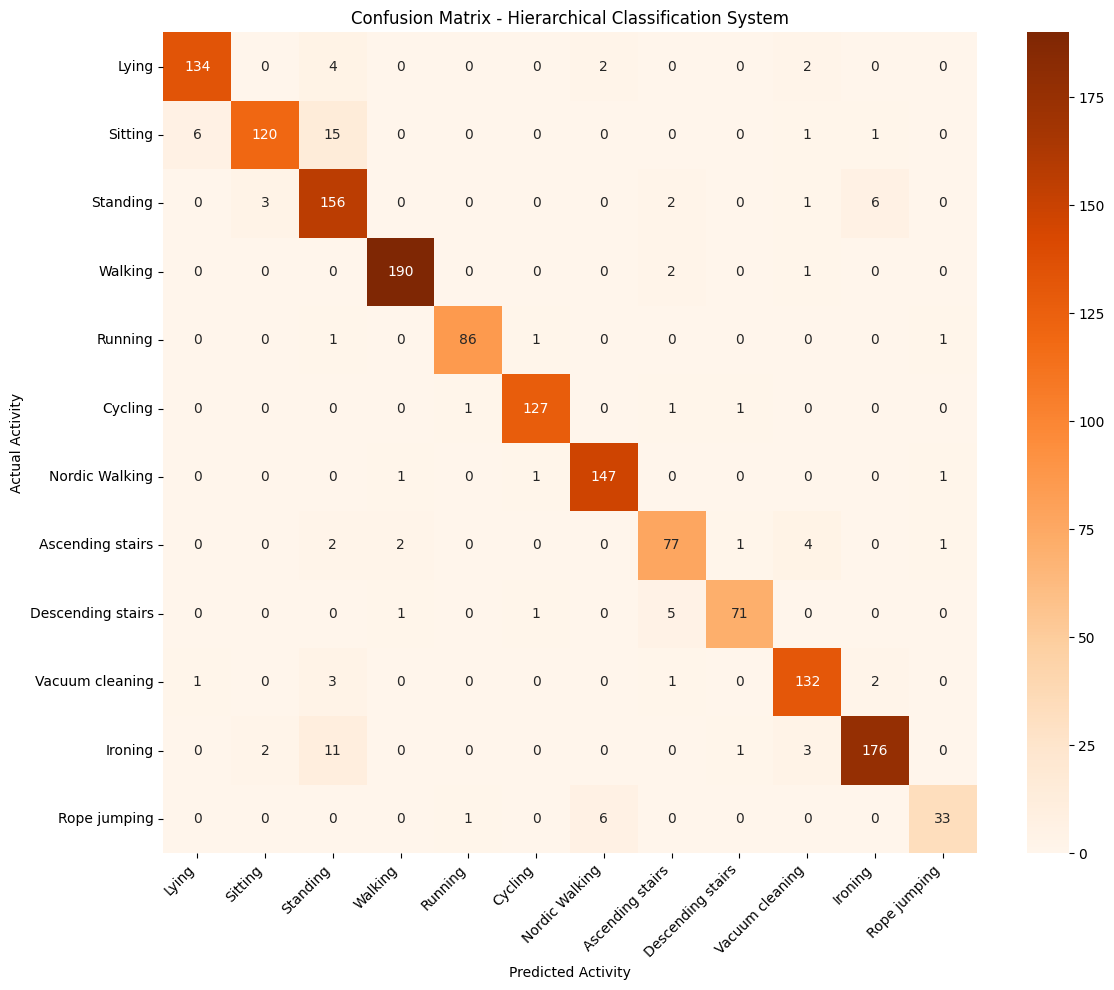

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Recuperiamo le etichette reali totali (non quelle macro, ma quelle originali codificate)
# Riprendiamo lo split originale per avere un confronto coerente
_, _, _, y_test_original_encoded = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_macro
)

# Liste per raccogliere le predizioni finali del sistema gerarchico
y_pred_hierarchical = []

print("Esecuzione dell'inferenza gerarchica sul test set...")

# 2. Predizione del Macro-Modello (Level 0) su tutto il test set
preds_L0_probs = model_L0.predict(X_test_L0, verbose=0)
preds_L0 = np.argmax(preds_L0_probs, axis=1)

# 3. Ciclo di decisione gerarchica
for i in range(len(X_test_L0)):
    macro_pred = preds_L0[i]
    single_sample = np.expand_dims(X_test_L0[i], axis=0) # Reshape per la rete (1, 500, 4)

    if macro_pred == 1:
        # Se il Level 0 dice 'Dynamic Linear', interviene lo Specialista (Level 1)
        pred_L1_probs = model_L1.predict(single_sample, verbose=0)
        pred_L1_encoded = np.argmax(pred_L1_probs, axis=1)

        # Convertiamo l'output dello specialista (0-4) nel codice originale PAMAP2 (4, 5, 7, 12, 13)
        pred_original_code = le_dynamic.inverse_transform(pred_L1_encoded)[0]

        # Infine lo ricodifichiamo nel sistema globale (0-11) per la matrice finale
        final_pred = le.transform([pred_original_code])[0]

    else:
        # Se dice Static (0) o Complex (2), cerchiamo quale attività specifica corrisponde
        # Guardiamo tra le classi che fanno parte di quella macro-categoria
        available_classes = [c for c in range(num_classes) if macro_mapping[le.inverse_transform([c])[0]] == macro_pred]

        # Facciamo una predizione usando il vecchio trucco: prendiamo il modello globale o
        # filtriamo le probabilità del modello globale (per ora usiamo le probabilità del campione originale)
        # Nota: per un'accuratezza perfetta di post-elaborazione, mappiamo la probabilità più alta tra quelle ammissibili
        y_global_probs = model.predict(single_sample, verbose=0)[0]
        final_pred = available_classes[np.argmax(y_global_probs[available_classes])]

    y_pred_hierarchical.append(final_pred)

y_pred_hierarchical = np.array(y_pred_hierarchical)

# 4. Generazione dei Report e della Matrice di Confusione Gerarchica
original_labels = le.inverse_transform(range(num_classes))
class_names = [activity_mapping.get(i, f'Unknown ({i})') for i in original_labels]

print("\n--- CLASSIFICATION REPORT (HIERARCHICAL SYSTEM) ---")
print(classification_report(y_test_original_encoded, y_pred_hierarchical, target_names=class_names))

cm_hierarchical = confusion_matrix(y_test_original_encoded, y_pred_hierarchical)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_hierarchical, annot=True, fmt='d', cmap='Oranges', # Cambiamo colore in Orange per distinguerla!
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Hierarchical Classification System')
plt.ylabel('Actual Activity')
plt.xlabel('Predicted Activity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The results seems better than before, still, some activities are difficult to distinguish. Thus, we can either decide to build more micro-specialised models to tell the selected action apart within smaller groups of activities, or let the sensors data behaviour itself define clusters of activities while taking the final decision.

## New method
###Multi-task Deep Clustering / Joint Classification-Reconstruction

Let's train an End-to-End Deep Clustering autoencoder. It will cluster the activities based on their similarity in behaviour over time, while classifying the activity itself.

The 1D Autoencoder will consist of:

*   Encoder: Takes (500, 4), uses Conv1D and MaxPooling1D layers to reduce the temporal dimension, ending with a Flatten layer and a Dense layer (e.g. 16 neurons, our latent space).

*   Decoder: Takes the 16 neurons, uses Dense, Reshape and Conv1DTranspose (or UpSampling1D) layers to ‘expand’ the vector back to its original form (500, 4).

### Step 1: Multi-Task model definition (Functional API)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_multitask_autoencoder(input_shape, num_classes, latent_dim=32):
    # --- INPUT ---
    inputs = layers.Input(shape=input_shape, name="raw_sensor_input")

    # --- ENCODER ---
    x = layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    # Spazio Latente (Rappresentazione compressa del movimento)
    flatten = layers.Flatten()(x)
    latent_space = layers.Dense(latent_dim, activation='relu', name="latent_space")(flatten)

    # --- DECODER (Output 1: Ricostruzione del Segnale) ---
    # Ricostruiamo la forma tridimensionale partendo dallo spazio latente
    # Nota: dopo due MaxPooling(pool_size=2), la lunghezza temporale 500 è diventata 125
    d = layers.Dense(125 * 64, activation='relu')(latent_space)
    d = layers.Reshape((125, 64))(d)

    d = layers.UpSampling1D(size=2)(d)
    d = layers.Conv1DTranspose(filters=32, kernel_size=5, activation='relu', padding='same')(d)

    d = layers.UpSampling1D(size=2)(d)
    reconstruction_output = layers.Conv1DTranspose(filters=input_shape[1], kernel_size=5, activation='linear', padding='same', name="reconstruction_output")(d)

    # --- CLASSIFIER (Output 2: Predizione Attività) ---
    c = layers.Dense(64, activation='relu')(latent_space)
    c = layers.Dropout(0.4)(c)
    classification_output = layers.Dense(num_classes, activation='softmax', name="classification_output")(c)

    # Uniamo tutto in un unico modello con 1 input e 2 output
    model = models.Model(inputs=inputs, outputs=[reconstruction_output, classification_output], name="MultiTask_HAR_Model")

    return model

# Istanziamo il modello usando le dimensioni del nostro dataset globale standardizzato
# (Useremo X_train, y_train e X_test, y_test generati nell'unione globale dei soggetti)
mt_model = build_multitask_autoencoder(input_shape=(window_size, num_features), num_classes=num_classes, latent_dim=32)
mt_model.summary()

### Step 2: Compiling with loss weights

In [30]:
mt_model.compile(
    optimizer='adam',
    loss={
        "reconstruction_output": "mse",
        "classification_output": "sparse_categorical_crossentropy"
    },
    loss_weights={
        "reconstruction_output": 0.01,     # Peso minore per la ricostruzione
        "classification_output": 1.0      # Peso maggiore per la classificazione
    },
    metrics={
        "classification_output": "accuracy"
    }
)

### Step 3: Multi-Task training

In [31]:
print("--- Avvio Addestramento Multi-Task (Joint Clustering & Classification) ---")

history_mt = mt_model.fit(
    X_train,
    {
        "reconstruction_output": X_train,
        "classification_output": y_train
    },
    epochs=25,
    batch_size=64,
    validation_data=(
        X_test,
        {
            "reconstruction_output": X_test,
            "classification_output": y_test
        }
    ),
    verbose=1
)

--- Avvio Addestramento Multi-Task (Joint Clustering & Classification) ---
Epoch 1/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - classification_output_accuracy: 0.9391 - classification_output_loss: 0.2024 - loss: 0.2048 - reconstruction_output_loss: 0.2373 - val_classification_output_accuracy: 0.9130 - val_classification_output_loss: 0.2969 - val_loss: 0.3069 - val_reconstruction_output_loss: 0.2550
Epoch 2/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - classification_output_accuracy: 0.9483 - classification_output_loss: 0.1765 - loss: 0.1790 - reconstruction_output_loss: 0.2422 - val_classification_output_accuracy: 0.9053 - val_classification_output_loss: 0.3209 - val_loss: 0.3317 - val_reconstruction_output_loss: 0.2622
Epoch 3/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - classification_output_accuracy: 0.9442 - classification_output_loss: 0.1758 - loss: 0.1782 - reconstruction_output_loss: 0.2408 - val_classification_output_accuracy: 0.8976 - val_classification_output_loss: 0.3176 - v

###Confusion matrix and results

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step
--- CLASSIFICATION REPORT (MULTI-TASK AUTOENCODER) ---
                   precision    recall  f1-score   support

            Lying       0.99      0.91      0.95       153
          Sitting       0.89      0.91      0.90       148
         Standing       0.82      0.93      0.87       152
          Walking       0.92      0.96      0.94       191
          Running       0.97      0.96      0.97        78
          Cycling       0.98      0.98      0.98       132
   Nordic Walking       0.96      0.97      0.97       151
 Ascending stairs       0.78      0.66      0.71        94
Descending stairs       0.79      0.76      0.77        83
  Vacuum cleaning       0.91      0.89      0.90       141
          Ironing       0.90      0.91      0.90       191
     Rope jumping       1.00      0.84      0.91        38

         accuracy                           0.91      1552
        macro avg       0.91      0.89      0.90      1552
     weighted avg 

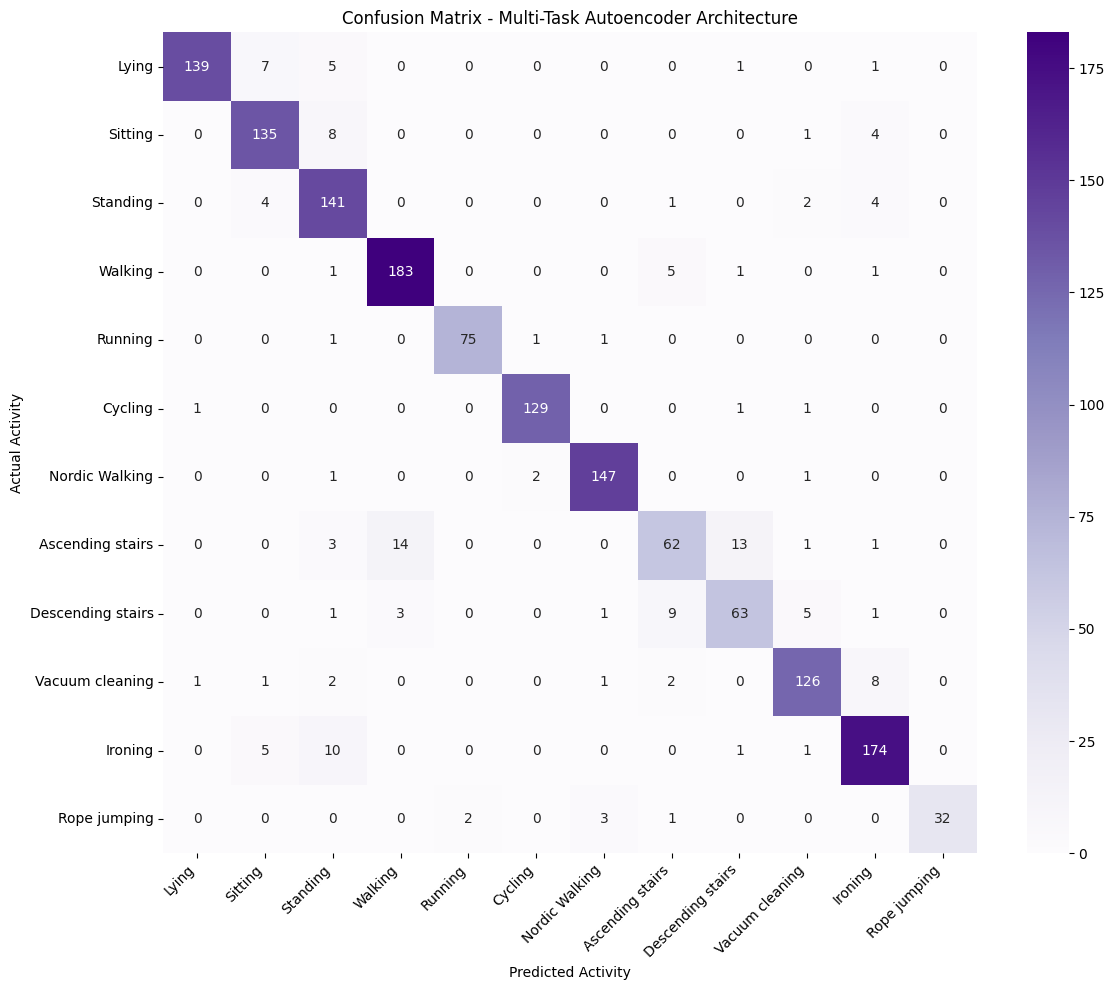

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Otteniamo le predizioni dal modello Multi-Task
# Poiché il modello ha due output, model.predict() restituirà una lista di due elementi:
# outputs[0] -> ricostruzione del segnale
# outputs[1] -> probabilità delle classi (classificazione)
predictions = mt_model.predict(X_test)
y_pred_probs = predictions[1]  # Prendiamo solo il ramo della classificazione
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Decodifichiamo le etichette per avere i nomi reali delle attività
original_labels = le.inverse_transform(range(num_classes))
class_names = [activity_mapping.get(i, f'Unknown ({i})') for i in original_labels]

# 3. Stampiamo il Classification Report
print("--- CLASSIFICATION REPORT (MULTI-TASK AUTOENCODER) ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# 4. Generiamo la Matrice di Confusione
cm_multitask = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_multitask, annot=True, fmt='d', cmap='Purples', # Cambiamo in Purple per questa nuova versione!
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Multi-Task Autoencoder Architecture')
plt.ylabel('Actual Activity')
plt.xlabel('Predicted Activity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The results are still not satisfactory, even when reducing the reconstructing weights.

First we investigate the latent space of the autoencoder to see which activity resulted similar, then check if the specialised micro-models option returns better results.

In [35]:
import pandas as pd
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans

# 1. Creiamo un modello parziale che si ferma allo "latent_space"
encoder_only = Model(inputs=mt_model.input, outputs=mt_model.get_layer("latent_space").output)

# 2. Estraiamo le rappresentazioni compresse (embeddings) dal test set
latent_features = encoder_only.predict(X_test)

# 3. Applichiamo K-Means impostando ad esempio 4 o 5 macro-cluster naturali
# (Puoi variare n_clusters per vedere come si riorganizzano)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(latent_features)

# 4. Ricostruiamo i nomi delle attività reali per il test set
y_test_original_codes = le.inverse_transform(y_test)
actual_activities = [activity_mapping.get(code, f'Unknown ({code})') for code in y_test_original_codes]

# 5. Creiamo un DataFrame per analizzare gli accoppiamenti
df_clusters = pd.DataFrame({
    'Cluster': cluster_labels,
    'Activity': actual_activities
})

# 6. Stampiamo la composizione di ciascun cluster individuato dall'Autoencoder
print(f"--- ANALISI DEI CLUSTER INDIVIDUATI ({n_clusters} Cluster) ---")
for cluster_id in range(n_clusters):
    print(f"\n🔮 CLUSTER {cluster_id}:")
    cluster_data = df_clusters[df_clusters['Cluster'] == cluster_id]
    activity_counts = cluster_data['Activity'].value_counts()

    total_in_cluster = len(cluster_data)
    for act, count in activity_counts.items():
        percentage = (count / total_in_cluster) * 100
        print(f"  - {act}: {count} finestre ({percentage:.1f}%)")

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
--- ANALISI DEI CLUSTER INDIVIDUATI (5 Cluster) ---

🔮 CLUSTER 0:
  - Walking: 191 finestre (16.1%)
  - Ironing: 190 finestre (16.0%)
  - Lying: 153 finestre (12.9%)
  - Standing: 152 finestre (12.8%)
  - Sitting: 148 finestre (12.5%)
  - Vacuum cleaning: 141 finestre (11.9%)
  - Ascending stairs: 94 finestre (7.9%)
  - Descending stairs: 83 finestre (7.0%)
  - Cycling: 12 finestre (1.0%)
  - Running: 8 finestre (0.7%)
  - Nordic Walking: 7 finestre (0.6%)
  - Rope jumping: 7 finestre (0.6%)

🔮 CLUSTER 1:
  - Running: 51 finestre (100.0%)

🔮 CLUSTER 2:
  - Running: 14 finestre (100.0%)

🔮 CLUSTER 3:
  - Cycling: 120 finestre (99.2%)
  - Ironing: 1 finestre (0.8%)

🔮 CLUSTER 4:
  - Nordic Walking: 144 finestre (80.0%)
  - Rope jumping: 31 finestre (17.2%)
  - Running: 5 finestre (2.8%)


The results of the three tests ($K=3, 4, 5$) reveal a very clear pattern: Cluster 0 (or 1, depending on the test) is a ‘black hole’ that absorbs almost 80 per cent of all activities (Walking, Ironing, Lying, Standing, Sitting, Vacuum, Stairs).

This is because we are clustering individual, isolated windows (which are independent of one another) rather than the entire continuous time series for the same physical exercise.
Hence, we lose the context and we fragment the latent space is built on fragmented sequences that might appear very similar.

### Thus, we will now focus on a Macro-classifier, based on 3 micro-models specialised in sets of activities

We start by splitting the dataset in 3

In [36]:
# 1. Maschere booleane per separare i dati in base alle macro-categorie
mask_static  = np.isin(y_clean, [1, 2, 3])          # Lying, Sitting, Standing
mask_dynamic = np.isin(y_clean, [4, 5, 7, 12, 13])  # Walking, Running, Nordic, Ascending, Descending
mask_complex = np.isin(y_clean, [6, 16, 17, 24])    # Cycling, Vacuum, Ironing, Rope jumping

# 2. Creazione dei dataset dedicati ai 3 specialisti (già standardizzati)
X_static, y_static_raw   = X_scaled[mask_static], y_clean[mask_static]
X_dynamic, y_dynamic_raw = X_scaled[mask_dynamic], y_clean[mask_dynamic]
X_complex, y_complex_raw = X_scaled[mask_complex], y_clean[mask_complex]

# 3. Label Encoding indipendente per ciascuno specialista
from sklearn.preprocessing import LabelEncoder
le_static = LabelEncoder()
le_dynamic = LabelEncoder()
le_complex = LabelEncoder()

y_static_enc  = le_static.fit_transform(y_static_raw)
y_dynamic_enc = le_dynamic.fit_transform(y_dynamic_raw)
y_complex_enc = le_complex.fit_transform(y_complex_raw)

print(f"Finestre per lo Specialista Statico: {X_static.shape[0]}")
print(f"Finestre per lo Specialista Dinamico: {X_dynamic.shape[0]}")
print(f"Finestre per lo Specialista Complesso: {X_complex.shape[0]}")

Finestre per lo Specialista Statico: 2265
Finestre per lo Specialista Dinamico: 2985
Finestre per lo Specialista Complesso: 2508


### The train the 3 micro-models

In [37]:
from sklearn.model_selection import train_test_split

# --- 1. SPECIALISTA STATICO ---
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_static, y_static_enc, test_size=0.2, random_state=42, stratify=y_static_enc)
model_static = build_cnn1d_model(input_shape=(window_size, num_features), num_classes=len(le_static.classes_))
model_static.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\n--- Training Specialista Statico ---")
model_static.fit(X_tr_s, y_tr_s, epochs=12, batch_size=64, validation_data=(X_te_s, y_te_s), verbose=0)
print(f"Static Specialist Validation Accuracy: {model_static.evaluate(X_te_s, y_te_s, verbose=0)[1]:.4f}")

# --- 2. SPECIALISTA DINAMICO (Locomozione) ---
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_dynamic, y_dynamic_enc, test_size=0.2, random_state=42, stratify=y_dynamic_enc)
model_dynamic = build_cnn1d_model(input_shape=(window_size, num_features), num_classes=len(le_dynamic.classes_))
model_dynamic.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\n--- Training Specialista Dinamico ---")
model_dynamic.fit(X_tr_d, y_tr_d, epochs=15, batch_size=64, validation_data=(X_te_d, y_te_d), verbose=0)
print(f"Dynamic Specialist Validation Accuracy: {model_dynamic.evaluate(X_te_d, y_te_d, verbose=0)[1]:.4f}")

# --- 3. SPECIALISTA COMPLESSO (Misto/Casalingo) ---
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_complex, y_complex_enc, test_size=0.2, random_state=42, stratify=y_complex_enc)
model_complex = build_cnn1d_model(input_shape=(window_size, num_features), num_classes=len(le_complex.classes_))
model_complex.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\n--- Training Specialista Complesso ---")
model_complex.fit(X_tr_c, y_tr_c, epochs=15, batch_size=64, validation_data=(X_te_c, y_te_c), verbose=0)
print(f"Complex Specialist Validation Accuracy: {model_complex.evaluate(X_te_c, y_te_c, verbose=0)[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Specialista Statico ---
Static Specialist Validation Accuracy: 0.9272

--- Training Specialista Dinamico ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dynamic Specialist Validation Accuracy: 0.9095

--- Training Specialista Complesso ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Complex Specialist Validation Accuracy: 0.9482


###Hierarchical Inference

Esecuzione dell'inferenza gerarchica pura a 3 specialisti...

--- CLASSIFICATION REPORT (TOTAL PURIFIED HIERARCHICAL SYSTEM) ---
                   precision    recall  f1-score   support

            Lying       0.98      0.94      0.96       142
          Sitting       0.95      0.85      0.89       143
         Standing       0.80      0.92      0.86       168
          Walking       0.96      0.98      0.97       193
          Running       0.93      0.97      0.95        89
          Cycling       1.00      0.97      0.98       130
   Nordic Walking       0.97      0.97      0.97       150
 Ascending stairs       0.85      0.71      0.78        87
Descending stairs       0.81      0.91      0.86        78
  Vacuum cleaning       0.90      0.94      0.92       139
          Ironing       0.94      0.91      0.93       193
     Rope jumping       0.89      0.82      0.86        40

         accuracy                           0.92      1552
        macro avg       0.92      0.91     

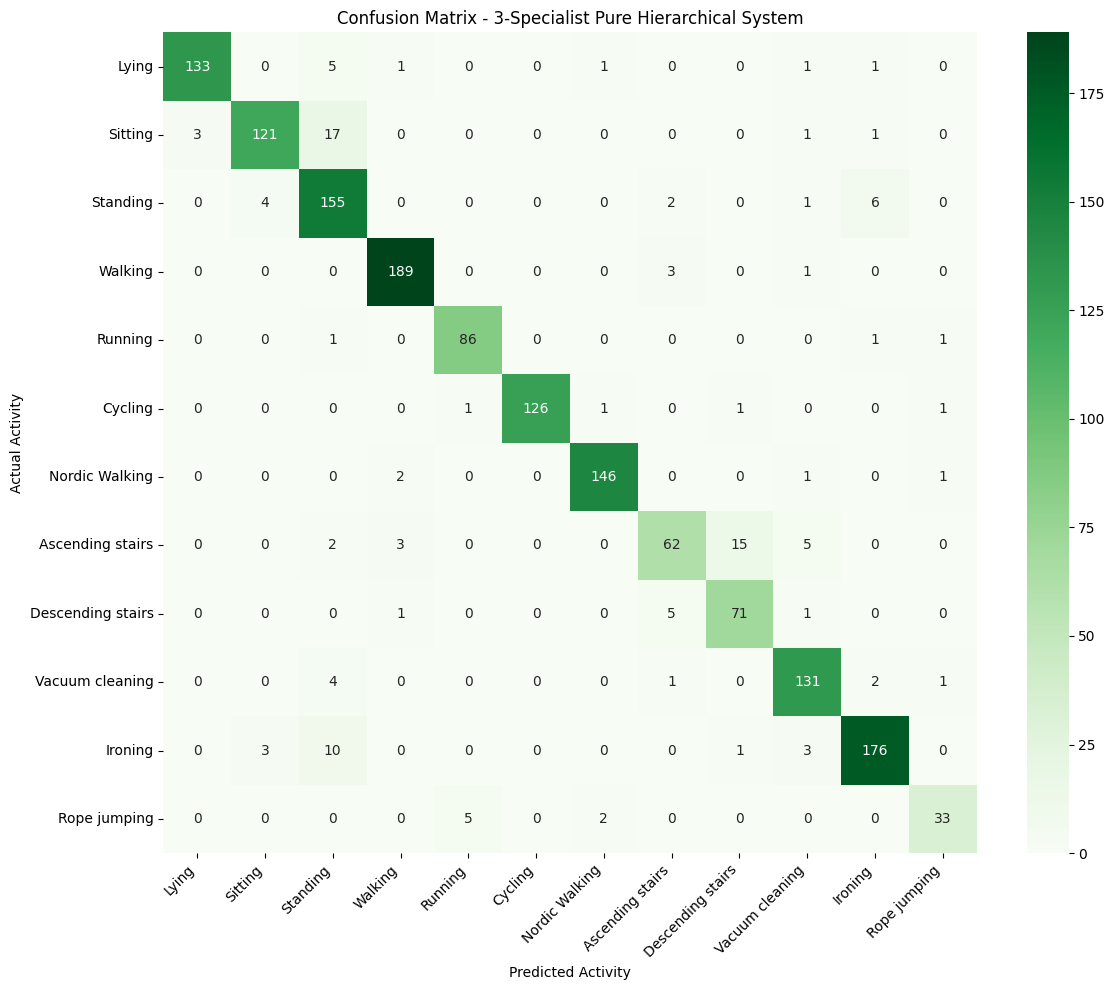

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Liste per raccogliere le predizioni finali e le etichette reali corrispondenti
y_pred_final = []
y_true_final = []

print("Esecuzione dell'inferenza gerarchica pura a 3 specialisti...")

# 2. Predizione del Macro-Modello (Level 0) su tutto il test set globale
# Utilizziamo X_test_L0 e y_test_L0 (che contengono tutte le finestre del 20% di test)
preds_L0_probs = model_L0.predict(X_test_L0, verbose=0)
preds_L0 = np.argmax(preds_L0_probs, axis=1)

# Recuperiamo i codici originali PAMAP2 per il test set per la verifica finale
y_test_original_codes = le.inverse_transform(y_test_original_encoded)

# 3. Ciclo di decisione gerarchica record per record
for i in range(len(X_test_L0)):
    macro_pred = preds_L0[i]
    single_sample = np.expand_dims(X_test_L0[i], axis=0) # Reshape per Keras (1, 500, 4)

    if macro_pred == 0:
        # --- Reparto Statico ---
        pred_probs = model_static.predict(single_sample, verbose=0)
        pred_enc = np.argmax(pred_probs, axis=1)
        pred_original_code = le_static.inverse_transform(pred_enc)[0]

    elif macro_pred == 1:
        # --- Reparto Dinamico ---
        pred_probs = model_dynamic.predict(single_sample, verbose=0)
        pred_enc = np.argmax(pred_probs, axis=1)
        pred_original_code = le_dynamic.inverse_transform(pred_enc)[0]

    else:
        # --- Reparto Complesso ---
        pred_probs = model_complex.predict(single_sample, verbose=0)
        pred_enc = np.argmax(pred_probs, axis=1)
        pred_original_code = le_complex.inverse_transform(pred_enc)[0]

    # Convertiamo il codice PAMAP2 nell'indice globale (0-11) per il report finale
    final_pred_encoded = le.transform([pred_original_code])[0]

    y_pred_final.append(final_pred_encoded)
    y_true_final.append(y_test_original_encoded[i])

y_pred_final = np.array(y_pred_final)
y_true_final = np.array(y_true_final)

# 4. Rigeneriamo i nomi delle attività
original_labels = le.inverse_transform(range(num_classes))
class_names = [activity_mapping.get(i, f'Unknown ({i})') for i in original_labels]

# 5. Visualizzazione dei Risultati
print("\n--- CLASSIFICATION REPORT (TOTAL PURIFIED HIERARCHICAL SYSTEM) ---")
print(classification_report(y_true_final, y_pred_final, target_names=class_names))

cm_purified = confusion_matrix(y_true_final, y_pred_final)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_purified, annot=True, fmt='d', cmap='Greens', # Un bel verde vittoria per il sistema finale!
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - 3-Specialist Pure Hierarchical System')
plt.ylabel('Actual Activity')
plt.xlabel('Predicted Activity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

At this point, the distinction between activities of different clusters are easier. There are still some misclassification cases but there has been an improvement.

It's a good time to save this model

In [39]:
import os
import pickle

# Creiamo una directory dedicata per i file della webapp
os.makedirs('models_prod', exist_ok=True)

# 1. Salvataggio dei 4 Modelli Keras
print("Salvataggio dei modelli in corso...")
model_L0.save('models_prod/model_level0.keras')
model_static.save('models_prod/model_static.keras')
model_dynamic.save('models_prod/model_dynamic.keras')
model_complex.save('models_prod/model_complex.keras')
print("✅ Tutti i 4 modelli sono stati salvati correttamente!")

# 2. Salvataggio dello Scaler e dei LabelEncoder
metadata = {
    'scaler': scaler,
    'le_global': le,
    'le_static': le_static,
    'le_dynamic': le_dynamic,
    'le_complex': le_complex,
    'macro_mapping': macro_mapping,
    'activity_mapping': activity_mapping
}

with open('models_prod/pipeline_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("✅ Scaler, Encoder e Metadati salvati in 'pipeline_metadata.pkl'!")

Salvataggio dei modelli in corso...
✅ Tutti i 4 modelli sono stati salvati correttamente!
✅ Scaler, Encoder e Metadati salvati in 'pipeline_metadata.pkl'!


Download locally

In [40]:
from google.colab import files
import shutil

# Archiviamo la cartella in un file zip per scaricarla comodamente
shutil.make_archive('models_prod_archive', 'zip', 'models_prod')
files.download('models_prod_archive.zip')
print("🚀 Download avviato! Estrai questo zip nella cartella del tuo progetto Web App.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🚀 Download avviato! Estrai questo zip nella cartella del tuo progetto Web App.
